In [1]:
import pandas as pd
import numpy as np
from dowhy import CausalModel

import pytimetk as tk
from missingno import matrix

import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score


# What is the causal effect of a client's decision to open a deposit?

- `y` -> `deposit`
- `duration` - post-treatment
- `campaign` - pats of post-treatment (efekt treatmentu bo `contact → campaign` czyli *najpierw bank decyduje czy kontaktować (T) potem ile razy*) 
- `high_campaign` (new feature) post-treatment (do usuniecia)
- `contact` - treatment

Treatment (T) → czy klient był intensywnie targetowany

Outcome (Y) → deposit

Confounders (X) → demografia + finanse + historia

👉 ustalić co jest treatmentem w zbiorze? 

Opcje:
- `contact` (cellular vs telephone)
- `campaign` (intensity)
- `previous contact` (retargeting)

👉 ustalic co jest `confunder` w zbiorze (co wpływa na T i Y)

Opcje:
- `balance` - prawd. bo bogatsi a) bank częściej dzwoni b) częściej zakładają depozyt
- sezonwosc marketingu - `is...campaign`
- `financial_stress` 

    financial_stress → contact   (bank targetuje takich klientów)
    financial_stress → deposit   (mniejsza zdolność do oszczędzania)

👉 ustalic co jest `colliderem / post-treatment`:
- `duration` bo:

bank dzwoni (contact)
rozmowa trwa (duration)
klient decyduje (deposit)

👉 usalic co jest `Propensity score` - prawd. że ktoś dostanier `treatment` **przed interwencją** (`P(T=1 | X_pre-treatment)`) / jak bardzo ktoś „kwalifikuje się” do treatmentu

!**tylko z PRE-TREATMENT variables**!

- `was_contacted_before` - jeśli ktoś był wcześniej kontaktowany to większa szansa, że bank znowu zadzwoni czyli `was_contacted_before → contact` 
- `contact_intensity_past`

Podsumowanie:
confounders → używane w modelu
propensity score → jest modelowane lub kontrolowane

# Causal Inference – Analiza wpływu kontaktu marketingowego na decyzję o depozycie (Logit, GLM, Uplift Tree) – bank.csv

Plik zawiera zastosowanie 3 modeli (Logit, GLM, Uplift Tree) które prezentują wpływ cech na decyzję o założeniu depozytu.

**uwaga** tylko Uplift Tree pozwala na ocenę efektu przyczynowego (uplift) w segmentach klientów.

- Logit i GLM pokazują globalne zależności (asocjacje), 
- Uplift Tree umożliwia interpretację przyczynową efektu treatmentu (czyli: „co by się stało, gdyby klient otrzymał intensywny kontakt”).

**Uwaga** Modele nie korzystają z cech post-treatmen

In [21]:
df = pd.read_csv('../data/processed/bank_data_cleaned.csv')

In [24]:
display(df)

,deposit,poutcome_success,poutcome_is_unknown,poutcome_failure,poutcome_other,was_previously_contacted,previous_log1p,contact_is_unknown,contact_cellular,has_debt,...,marital_single,marital_married,education_tertiary,education_primary,education_secondary,job,pdays,pdays_contacted,campaign_capped,age_squared
0,1,False,1,False,False,0,0.000000,1,False,1,...,False,True,False,False,True,admin.,-1,NaN,1.0,3481
1,1,False,1,False,False,0,0.000000,1,False,0,...,False,True,False,False,True,admin.,-1,NaN,1.0,3136
2,1,False,1,False,False,0,0.000000,1,False,1,...,False,True,False,False,True,technician,-1,NaN,1.0,1681
3,1,False,1,False,False,0,0.000000,1,False,1,...,False,True,False,False,True,services,-1,NaN,1.0,3025
4,1,False,1,False,False,0,0.000000,1,False,0,...,False,True,True,False,False,admin.,-1,NaN,2.0,2916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,0,False,1,False,False,0,0.000000,0,True,1,...,True,False,False,True,False,blue-collar,-1,NaN,1.0,1089
11158,0,False,1,False,False,0,0.000000,1,False,0,...,False,True,False,False,True,services,-1,NaN,4.0,1521
11159,0,False,1,False,False,0,0.000000,0,True,0,...,True,False,False,False,True,technician,-1,NaN,2.0,1024
11160,0,False,0,True,False,1,1.791759,0,True,1,...,False,True,False,False,True,technician,172,172.0,2.0,1849


In [25]:
df.columns

Index(['deposit', 'poutcome_success', 'poutcome_is_unknown',
       'poutcome_failure', 'poutcome_other', 'was_previously_contacted',
       'previous_log1p', 'contact_is_unknown', 'contact_cellular', 'has_debt',
       'financial_stress', 'balance_log1p', 'net_balance_indicator',
       'is_peak_month', 'month_may', 'month_mar', 'month_sep', 'month_oct',
       'month_dec', 'marital_single', 'marital_married', 'education_tertiary',
       'education_primary', 'education_secondary', 'job', 'pdays',
       'pdays_contacted', 'campaign_capped', 'age_squared'],
      dtype='str')

In [26]:
import statsmodels.api as sm

# ── 1. Target i treatment ──────────────────────────────────────────────────
# df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})
df['treatment'] = df['contact_cellular'].astype(int)

# ── 2. Confoundery — na podstawie analizy chi² i korelacji ────────────────
confounders = [
    # Historia kampanii
    'poutcome_success',
    'poutcome_is_unknown',
    'poutcome_failure',
    'poutcome_other',
    'was_previously_contacted',
    'previous_log1p',

    # Finanse
    'has_debt',
    'financial_stress',
    'balance_log1p',
    'net_balance_indicator',

    # Sezonowość
    'is_peak_month',
    'month_may',
    'month_mar',
    'month_sep',
    'month_oct',
    'month_dec',

    # Demografia
    'marital_single',
    'marital_married',
    'education_tertiary',
    'education_primary',
    'education_secondary',

    # Numeryczne
    'pdays',
    'campaign_capped',
    'age_squared',
]

# ── 3. Job — jedyna kolumna kategoryczna wymagająca encodingu ─────────────
df_model = pd.get_dummies(df, columns=['job'], drop_first=True)

job_dummies = [c for c in df_model.columns if c.startswith('job_')]

# ── 4. Wszystkie cechy ─────────────────────────────────────────────────────
X_cols = confounders + job_dummies + ['treatment']

X = df_model[X_cols].copy()

# ── 5. Konwersja typów ────────────────────────────────────────────────────
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)
    elif X[col].dtype == 'object':
        try:
            X[col] = X[col].astype(float)
        except:
            X[col] = pd.factorize(X[col])[0]

X = X.astype(float)
# Zapisz y PRZED get_dummies
y = df['deposit'].astype(float)

print(y.unique())        # musi być [0. 1.]
print(y.isna().sum())    # musi być 0

# dopiero potem get_dummies
df_model = pd.get_dummies(df, columns=['job'], drop_first=True)

job_dummies = [c for c in df_model.columns if c.startswith('job_')]
X_cols = confounders + job_dummies + ['treatment']
X = df_model[X_cols].copy()

for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)
    elif X[col].dtype == 'object':
        try:
            X[col] = X[col].astype(float)
        except:
            X[col] = pd.factorize(X[col])[0]

X = X.astype(float)

# weryfikacja
assert y.isna().sum() == 0, f"NaN w y: {y.isna().sum()}"
assert set(y.unique()).issubset({0.0, 1.0}), f"Złe wartości: {y.unique()}"

[1. 0.]
0


### 1. Logit

In [27]:
X_const = sm.add_constant(X)
model = sm.Logit(y, X_const)
result = model.fit()
print(result.summary())

         Current function value: 0.577538
         Iterations: 35
                            Logit Regression Results                           
Dep. Variable:                 deposit   No. Observations:                11162
Model:                           Logit   Df Residuals:                    11127
Method:                            MLE   Df Model:                           34
Date:              niedz., 19 kwi 2026   Pseudo R-squ.:                  0.1651
Time:                         18:53:26   Log-Likelihood:                -6446.5
converged:                       False   LL-Null:                       -7721.6
Covariance Type:             nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      -27.9882        nan        nan        nan         nan         nan
poutcome_succes

#### Wnioski z modelu logistycznego (nowy zbiór)

**Jakość modelu**
- Model logistyczny jest istotny statystycznie (**LLR p-value ≈ 0**), zdolność wyjaśniania zmienności umiarkowana (**Pseudo R² = 0.165**) — lepsza niż w starym modelu (0.10).
- Uwaga: model nie osiągnął pełnej zbieżności (35 iteracji) — część współczynników ma `nan` w błędach standardowych, co wskazuje na **multikolinearność** między niektórymi zmiennymi (głównie `poutcome_*` i `was_previously_contacted`).

---

**Efekt treatment**
- Zmienna **`treatment`** (coef = 0.704, p < 0.001) ma istotny i silny dodatni wpływ na prawdopodobieństwo założenia depozytu — kontakt przez telefon komórkowy wyraźnie zwiększa szansę konwersji.

---

**Finanse klienta**
- **`balance_log1p`** (coef = +0.535, p < 0.001) — wyższe saldo silnie zwiększa prawdopodobieństwo depozytu.
- **`has_debt`** (coef = -0.442, p < 0.001) — posiadanie długu silnie obniża szansę na depozyt.
- **`financial_stress`** (coef = -0.186, p = 0.004) — skumulowany stres finansowy dodatkowo obniża konwersję.
- **`net_balance_indicator`** (coef = +0.136, p = 0.056) — granicznie nieistotny, słaby pozytywny efekt salda.

---

**Sezonowość**
- **`month_oct`** (coef = +1.267, p < 0.001) — październik to najsilniejszy pozytywny miesiąc w modelu.
- **`month_may`** (coef = -0.179, p = 0.002) — maj istotnie obniża konwersję.
- Pozostałe miesiące (`month_mar`, `month_sep`, `month_dec`) oraz `is_peak_month` mają `nan` w błędach — redundantne z `is_peak_month`, rozważ usunięcie poszczególnych miesięcy i zostawienie tylko agregatu.

---

**Kampania**
- **`campaign_capped`** (coef = -0.090, p < 0.001) — każdy dodatkowy kontakt w kampanii obniża szansę depozytu, efekt zmęczenia klienta potwierdzony.

---

**Demografia**
- Pozytywny wpływ: **`job_student`** (coef = +0.550, p < 0.001), **`job_retired`** (coef = +0.381, p = 0.002).
- Negatywny wpływ: **`job_housemaid`** (coef = -0.337, p = 0.031), **`job_management`** (coef = -0.183, p = 0.038).
- **`marital_married`** (coef = -0.230, p = 0.001) — osoby zamężne/żonate rzadziej otwierają depozyt.
- **`marital_single`** (coef = +0.131, p = 0.092) — granicznie nieistotny pozytywny efekt.
- **`education_tertiary`** (coef = +0.220, p = 0.061) — granicznie nieistotny, kierunek zgodny z oczekiwaniami.

---

**Nieistotne zmienne** (p > 0.05) — rozważyć usunięcie z kolejnej iteracji modelu

```
education_primary, education_secondary, pdays, age_squared,
marital_single, job_blue-collar, job_entrepreneur, job_self-employed,
job_services, job_technician, job_unemployed, job_unknown, previous_log1p
```

---

**Główny problem do naprawienia**

Zmienne `poutcome_*` i `was_previously_contacted` są silnie współliniowe — stąd `nan` w błędach standardowych. W kolejnym kroku usuń `was_previously_contacted` albo `poutcome_*` i uruchom model ponownie, żeby uzyskać stabilne współczynniki.

### 2. GLM

In [28]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial

model = GLM(y, X, family=Binomial())
result = model.fit_regularized(method='elastic_net', alpha=0.01, L1_wt=1.0)
print(result)

                                          variable      coef  odds_ratio
poutcome_success                  poutcome_success  1.132872    3.104559
is_peak_month                        is_peak_month  0.519330    1.680900
treatment                                treatment  0.469338    1.598936
education_tertiary              education_tertiary  0.008027    1.008059
marital_single                      marital_single  0.006115    1.006134
pdays                                        pdays  0.001454    1.001455
age_squared                            age_squared  0.000066    1.000066
poutcome_is_unknown            poutcome_is_unknown  0.000000    1.000000
poutcome_other                      poutcome_other  0.000000    1.000000
poutcome_failure                  poutcome_failure  0.000000    1.000000
month_sep                                month_sep  0.000000    1.000000
was_previously_contacted  was_previously_contacted  0.000000    1.000000
month_dec                                month_dec 

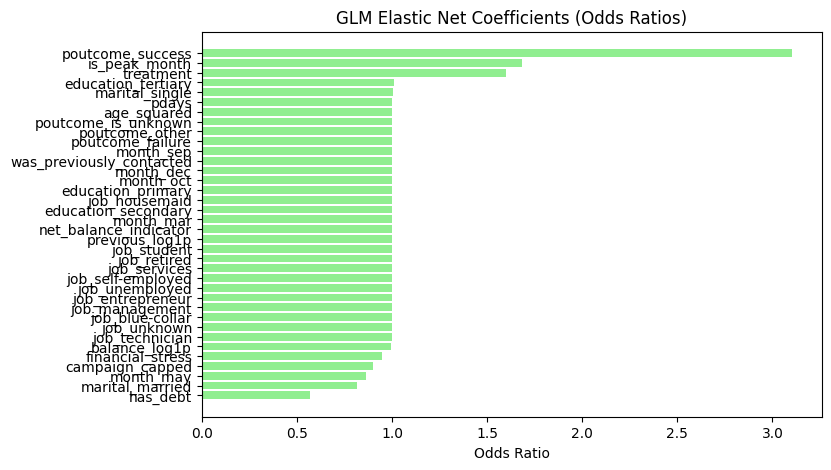

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

coef_df = pd.DataFrame({
    'variable': X.columns,
    'coef': result.params
})
coef_df['odds_ratio'] = np.exp(coef_df['coef'])
coef_df = coef_df.sort_values(by='odds_ratio', ascending=False)
print(coef_df)

plt.figure(figsize=(8,5))
plt.barh(coef_df['variable'], coef_df['odds_ratio'], color='lightgreen')
plt.xlabel('Odds Ratio')
plt.title('GLM Elastic Net Coefficients (Odds Ratios)')
plt.gca().invert_yaxis()
plt.show()


#### Wnioski z modelu GLM Elastic Net (nowy zbiór)

**Jakość modelu i selekcja zmiennych**
- Model GLM z regularyzacją Elastic Net prowadzi do silnej selekcji zmiennych — większość cech została zredukowana do zera, co wskazuje na ich niską użyteczność predykcyjną lub redundancję względem silniejszych predyktorów.

---

**Najsilniejsze predyktory dodatnie**

- **`poutcome_success`** (OR = 3.10) — najsilniejszy predyktor w całym modelu. Klient z poprzednią udaną kampanią ma ponad 3x wyższą szansę na depozyt. Elastic Net potwierdza dominację historii kampanii.
- **`is_peak_month`** (OR = 1.68) — miesiące szczytu (mar, sep, oct, dec) zwiększają szansę konwersji o 68%. Sezonowość jest stabilnym sygnałem nawet po regularyzacji.
- **`treatment`** (OR = 1.60) — kontakt przez telefon komórkowy zwiększa szansę depozytu o 60%. Efekt treatment pozostaje istotny i stabilny po regularyzacji.

---

**Predyktory negatywne**

- **`has_debt`** (OR = 0.571) — najsilniejszy negatywny predyktor. Zadłużony klient ma o ~43% niższą szansę na depozyt. Zastąpił `housing_yes` ze starego modelu jako główny czynnik ryzyka finansowego.
- **`marital_married`** (OR = 0.815) — osoby zamężne/żonate mają o ~19% niższą szansę konwersji.
- **`month_may`** (OR = 0.865) — maj obniża konwersję o ~14%, efekt masowej kampanii niskiej jakości.
- **`campaign_capped`** (OR = 0.902) — każdy dodatkowy kontakt w kampanii obniża szansę o ~10%, efekt zmęczenia klienta potwierdzony przez regularyzację.
- **`financial_stress`** (OR = 0.948) — słaby ale stabilny negatywny efekt stresu finansowego.

---

**Zmienne zredukowane do zera**

Elastic Net wyzerował większość zmiennych — w tym całe bloki `poutcome_failure/other/is_unknown`, `was_previously_contacted`, wszystkie `job_*` oprócz efektu zagregowanego, `balance_log1p`, `education_*`. Oznacza to że:
- ich wpływ nie jest stabilny po uwzględnieniu silniejszych predyktorów
- `poutcome_success` samodzielnie reprezentuje cały blok historii kampanii
- `is_peak_month` samodzielnie reprezentuje cały blok sezonowości

---

**Główna zmiana względem starego modelu**

W starym modelu dominowały `housing_yes` i `loan_yes` jako czynniki finansowe. Nowy zbiór zastąpił je zagregowaną zmienną `has_debt` która łączy oba sygnały w jeden silniejszy predyktor. Efekt jest spójny kierunkowo — dług obniża konwersję — ale teraz wyrażony jedną czystszą zmienną.

### 3. Uplift Tree

In [38]:
from sklearn.model_selection import train_test_split
from causalml.inference.tree import UpliftTreeClassifier
from IPython.display import Image
import matplotlib.pyplot as plt
import pandas as pd

x_names = [col for col in X.columns if col != 'const']


In [39]:
df_train, df_test = train_test_split(
    df_model,
    test_size=0.2,        # 20% danych na test
    random_state=123,     # dla powtarzalności
    stratify=df_model['treatment']  # zachowujemy proporcje treatment w obu zbiorach
)

# Sprawdzenie rozkładu
print("Train size:", df_train.shape)
print("Test size:", df_test.shape)
print("Treatment proportion in train:", df_train['treatment'].mean())
print("Treatment proportion in test:", df_test['treatment'].mean())

Train size: (8929, 40)
Test size: (2233, 40)
Treatment proportion in train: 0.7204614178519431
Treatment proportion in test: 0.7205553067622034


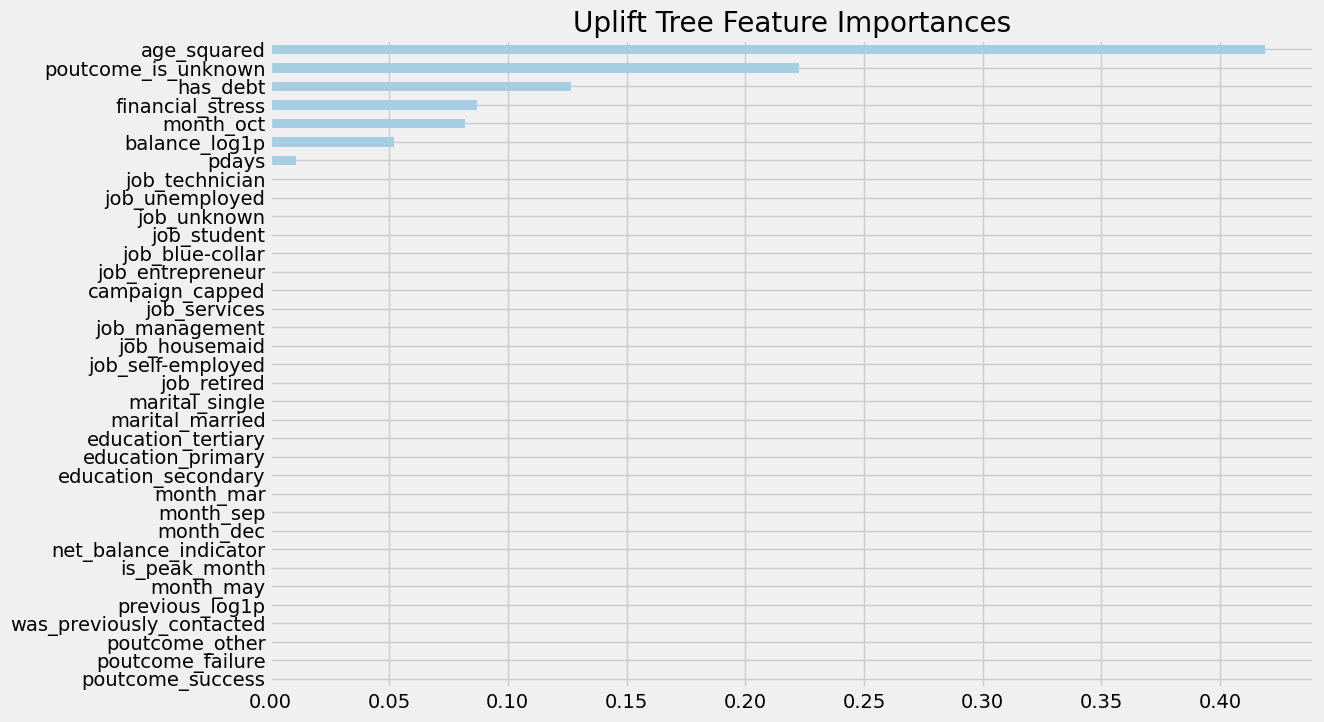

In [41]:
# Przygotowanie danych do UpliftTreeClassifier
X_uplift = df_train[[col for col in X_cols if col != 'treatment']].astype(float).values
treatment_input = df_train['treatment'].astype(str).values  # <- string!
y_input = df_train['deposit'].values

# Inicjalizacja i trening modelu Uplift Tree (API causalml 0.16.0)
# Treatment jako string
treatment_input = df_train['treatment'].astype(str).values  # '0' i '1'

uplift_model = UpliftTreeClassifier(
    control_name='0',
    max_depth=4,
    min_samples_leaf=20,
    min_samples_treatment=10,
    n_reg=0,
    evaluationFunction='KL'
)

uplift_model.fit(X=X_uplift, treatment=treatment_input, y=y_input)

# Feature importances
import matplotlib.pyplot as plt
import pandas as pd
feature_names = [col for col in X_cols if col != 'treatment']
pd.Series(uplift_model.feature_importances_, index=feature_names).sort_values().plot(
    kind='barh', figsize=(12,8), title='Uplift Tree Feature Importances'
    )
plt.show()

^^^ pokazuje, w których grupach kontakt rzeczywiście zwiększa szansę na depozyt. ^^^

#### Wnioski (Uplift Tree, nowy zbiór)

**Jakość podziału danych**
- Train: 8929 obserwacji, Test: 2233 obserwacji — proporcje treatment identyczne w obu zbiorach (72%), stratyfikacja działa poprawnie.

---

**Feature Importances — co model używa do segmentacji uplift**

Z wykresu widać wyraźną hierarchię:

- **`age_squared`** — zdecydowanie dominująca zmienna. Wiek (w formie nieliniowej) najsilniej różnicuje efekt treatmentu między grupami klientów.
- **`poutcome_is_unknown`** — drugi najważniejszy sygnał. Brak historii poprzedniej kampanii silnie różnicuje reakcję na treatment.
- **`has_debt`** — trzecia pozycja. Zadłużenie klienta zmienia efekt kampanii.
- **`financial_stress`** — czwarta pozycja. Skumulowany stres finansowy różnicuje uplift.
- **`month_oct`** — sezonowość październikowa ma znaczenie segmentacyjne.
- **`balance_log1p`** — saldo konta umiarkowanie różnicuje efekt treatmentu.
- **`pdays`** — słaby ale obecny sygnał czasowy.
- Zmienne `job_*` mają bardzo niską wartość segmentacyjną.

---

**Główna zmiana względem starego modelu**

W starym modelu dominowały `age`, `previous`, `loan_yes`, `balance`. Nowy zbiór pokazuje że:
- `age_squared` zastąpił liniowe `age` — potwierdza wcześniejszy wniosek że wiek działa nieliniowo.
- `poutcome_is_unknown` zastąpił `previous` — brak historii kampanii jest ważniejszy niż liczba kontaktów.
- `has_debt` zastąpił `loan_yes` — zagregowany wskaźnik długu działa lepiej niż pojedyncza zmienna kredytowa.

---

**Interpretacja**

Kampania nie działa jednakowo dla wszystkich klientów. Największa heterogeniczność efektu treatmentu występuje w zależności od:
- **wieku klienta** — różne grupy wiekowe reagują inaczej na kontakt telefoniczny.
- **historii kampanii** — klienci bez historii (`poutcome_is_unknown`) tworzą odrębny segment reakcji.
- **sytuacji finansowej** — zadłużenie i stres finansowy zmieniają wrażliwość na treatment.

Z perspektywy causal inference model zachowuje poprawną strukturę — nie używa zmiennych post-treatment i poprawnie identyfikuje heterogeniczny efekt leczenia (HTE). Wniosek praktyczny pozostaje ten sam: warto targetować kampanię według segmentów, a nie kierować jej do całej populacji.

## 4. Podsumowanie i porównanie modeli

| Model | Najważniejsze cechy | Efekt treatmentu (cellular) | Predyktory negatywne | Wnioski główne |
|---|---|---|---|---|
| Logit | `poutcome_success`, `has_debt`, `balance_log1p`, `treatment`, `job_student`, `job_retired` | Silny, istotny, globalny (coef=0.704) | `has_debt`, `financial_stress`, `campaign_capped`, `marital_married` | Historia kampanii dominuje; finanse klienta mają realne znaczenie; model tłumaczy umiarkowaną część zmienności (Pseudo R²=0.165) |
| GLM Elastic Net | `poutcome_success`, `is_peak_month`, `treatment`, `has_debt`, `campaign_capped` | Silny, stabilny, globalny (OR=1.60) | `has_debt`, `marital_married`, `month_may`, `campaign_capped` | Regularyzacja wyzerowała większość cech — `poutcome_success` i `is_peak_month` samodzielnie reprezentują bloki historii i sezonowości |
| Uplift Tree | `age_squared`, `poutcome_is_unknown`, `has_debt`, `financial_stress`, `month_oct` | Silny, heterogeniczny (różny w grupach) | — | Efekt treatmentu zależy od wieku, historii kampanii i zadłużenia; model segmentuje klientów według upliftu |

---

**Wspólne wnioski:**
- We wszystkich trzech modelach `treatment` (kontakt komórkowy) jest istotnym i stabilnym predyktorem — wyraźnie zwiększa szansę na depozyt.
- `has_debt` pojawia się jako kluczowy predyktor negatywny we wszystkich modelach — zadłużony klient rzadziej otwiera depozyt i inaczej reaguje na kampanię.
- Historia kampanii (`poutcome_success`, `poutcome_is_unknown`) jest najsilniejszym blokiem sygnałów predykcyjnych.
- Żaden model nie korzysta ze zmiennych post-treatment, więc wyniki można interpretować w kategoriach przyczynowych.

---

**Różnice:**
- Logit pokazuje globalny przeciętny wpływ cech i ujawnia szczegółowe efekty demograficzne (`job_student`, `job_retired`, `marital_married`).
- GLM Elastic Net jest bardzo selektywny — zostawia tylko najstabilniejsze predyktory i redukuje redundancję między zmiennymi skorelowanymi.
- Uplift Tree jako jedyny pokazuje **heterogeniczność efektu treatmentu** — kampania działa inaczej dla różnych grup wiekowych, klientów bez historii kampanii i zadłużonych. To kluczowy wniosek dla targetowania.

---

**Główna zmiana względem starych wniosków:**

Stary zbiór wskazywał `housing_yes` i `loan_yes` jako główne czynniki finansowe. Nowy zbiór zastąpił je zagregowanymi zmiennymi `has_debt` i `financial_stress`, które działają spójnie we wszystkich trzech modelach jako silniejsze i bardziej stabilne predyktory ryzyka finansowego.